In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.feature_extraction.text import CountVectorizer

In [2]:
# Load labels
y_test = np.load("../outputs/y_test.npy")

# Load baseline predictions
y_pred_nb = np.load("../outputs/y_pred_nb.npy")
y_pred_log = np.load("../outputs/y_pred_log.npy")

# Load advanced predictions
svm_preds = np.load("../outputs/svm_preds.npy")
xgb_preds = np.load("../outputs/xgb_preds.npy")

# Load Clean Reviews for Error Analysis

In [3]:
# Load 
X_test = pd.read_csv("../outputs/X_test_reviews.csv")



# Naive Bayes Evaluation

In [4]:
# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

# Precision
nb_precision = precision_score(y_test, y_pred_nb)

# Recall
nb_recall = recall_score(y_test, y_pred_nb)

# F1 Score
nb_f1 = f1_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Precision:", nb_precision)
print("Naive Bayes Recall:", nb_recall)
print("Naive Bayes F1-Score:", nb_f1)

Naive Bayes Accuracy: 0.8616
Naive Bayes Precision: 0.8670415746133762
Naive Bayes Recall: 0.8567176026989483
Naive Bayes F1-Score: 0.8618486723896985


In [5]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4961
           1       0.87      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



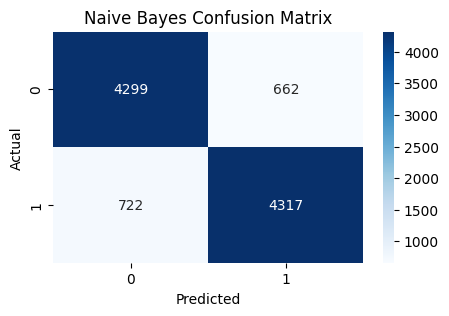

In [6]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

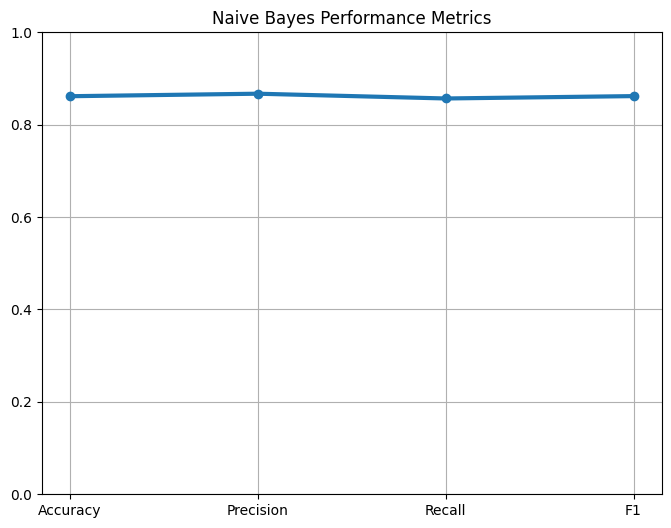

In [7]:
# Metric Plot
metrics = [nb_accuracy, nb_precision, nb_recall, nb_f1]
names = ['Accuracy', 'Precision', 'Recall', 'F1']

plt.figure(figsize=(8,6))
plt.plot(names, metrics, marker='o', linewidth=3)

plt.ylim(0,1)
plt.title("Naive Bayes Performance Metrics")
plt.grid(True)

plt.show()

In [8]:
# Error Analysis
errors = pd.DataFrame({
    'Text': X_test['clean_review'].reset_index(drop=True),
    'True_Label': y_test,
    'Predicted_Label': y_pred_nb
})

wrong = errors[
    errors['True_Label'] != errors['Predicted_Label']
]

wrong.head(10)

,Text,True_Label,Predicted_Label
7,okay didnt get purgatory thing first time watc...,1,0
17,first introduced john water film seeing female...,1,0
19,cant help notice negative review movie gotten ...,1,0
28,im writing note chess player well movie viewer...,0,1
29,three kid born solar eclipse turn vile murdero...,1,0
49,wasnt sure expect movie considering amazing co...,1,0
50,ruthless assassin hired eliminate someone top ...,0,1
58,although series mini film particular important...,0,1
61,longtime fan star trek seriesi found disappoin...,0,1
79,getting melange theme well covered many previo...,0,1


In [9]:
# Error Rate
print("Total Wrong Predictions:", len(wrong))
print("Total Test Samples:", len(y_test))
print("Error Rate:", len(wrong)/len(y_test))

Total Wrong Predictions: 1384
Total Test Samples: 10000
Error Rate: 0.1384


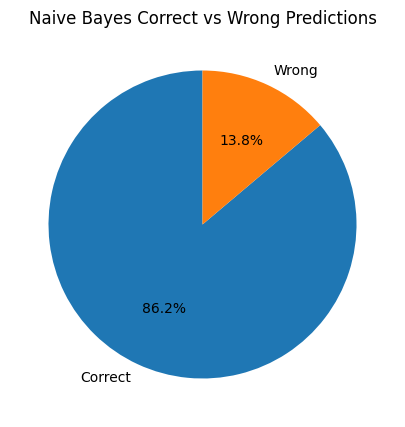

In [10]:
# Correct vs Wrong Predictions
correct = len(y_test) - len(wrong)
incorrect = len(wrong)

labels = ['Correct', 'Wrong']
values = [correct, incorrect]

plt.figure(figsize=(7,5))

plt.pie(values, labels=labels,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Naive Bayes Correct vs Wrong Predictions")

plt.show()

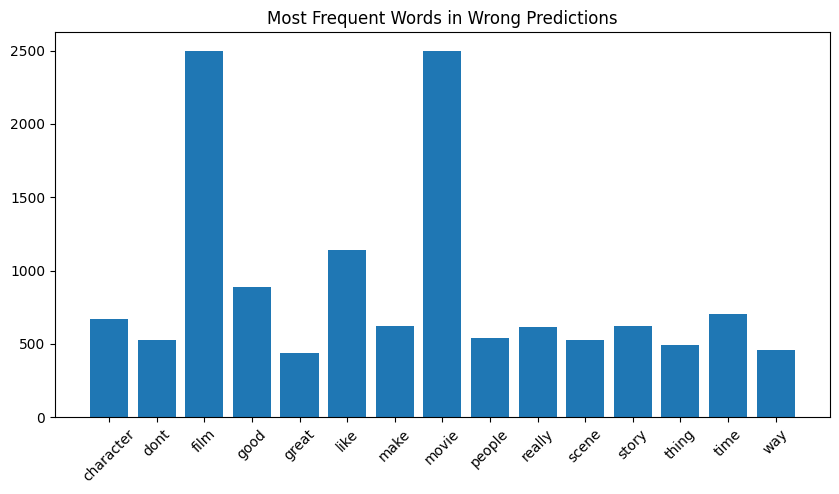

In [11]:
# Most Frequent Wrong Words
cv = CountVectorizer(stop_words='english', max_features=15)

X_err = cv.fit_transform(wrong['Text'].astype(str))

words = cv.get_feature_names_out()
counts = X_err.toarray().sum(axis=0)

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Most Frequent Words in Wrong Predictions")
plt.xticks(rotation=45)

plt.show()

# Logistic Regression Evaluation

In [12]:
# Metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression Precision:", log_precision)
print("Logistic Regression Recall:", log_recall)
print("Logistic Regression F1-Score:", log_f1)

Logistic Regression Accuracy: 0.8944
Logistic Regression Precision: 0.8852776165602632
Logistic Regression Recall: 0.9081166898194086
Logistic Regression F1-Score: 0.896551724137931


In [13]:
# Classification Report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



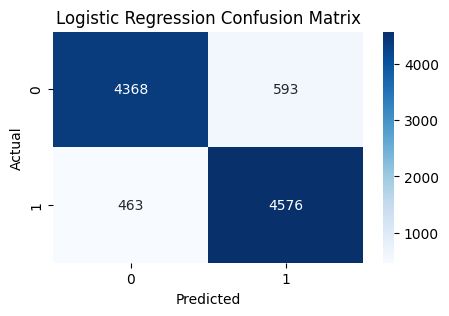

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

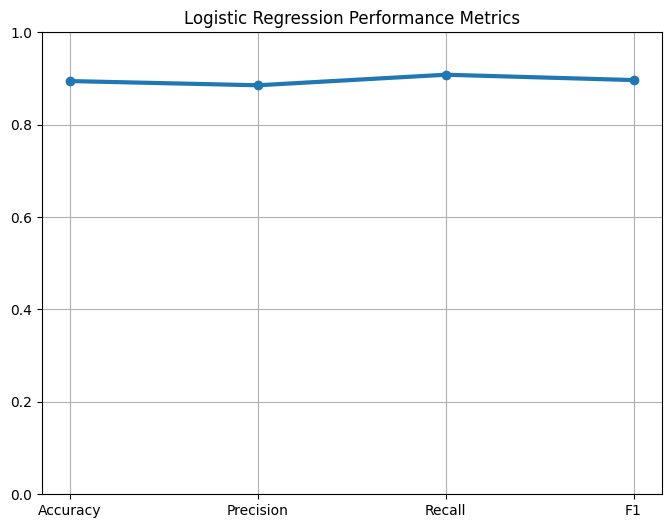

In [15]:
# Metrics Plot
metrics = [log_accuracy, log_precision, log_recall, log_f1]
names = ['Accuracy', 'Precision', 'Recall', 'F1']

plt.figure(figsize=(8,6))
plt.plot(names, metrics, marker='o', linewidth=3)

plt.ylim(0,1)
plt.title("Logistic Regression Performance Metrics")
plt.grid(True)

plt.show()

In [16]:
# Error Analysis
errors = pd.DataFrame({
    'Text': X_test['clean_review'].reset_index(drop=True),
    'True_Label': y_test,
    'Predicted_Label': y_pred_log
})

wrong = errors[
    errors['True_Label'] != errors['Predicted_Label']
]

wrong.head(10)

,Text,True_Label,Predicted_Label
0,really liked summerslam due look arena curtain...,1,0
7,okay didnt get purgatory thing first time watc...,1,0
15,movie start somewhat slowly get running toward...,1,0
23,movie released originally soft x apparently ex...,1,0
29,three kid born solar eclipse turn vile murdero...,1,0
41,though cant claim comic book fanatic read shar...,1,0
58,although series mini film particular important...,0,1
63,fact part liked lot interesting twist left see...,0,1
65,awesome story mode going punk pro complete goa...,1,0
69,ok imagine every state u nay every country exa...,0,1


In [17]:
# Error Rate
print("Total Wrong Predictions:", len(wrong))
print("Total Test Samples:", len(y_test))
print("Error Rate:", len(wrong)/len(y_test))

Total Wrong Predictions: 1056
Total Test Samples: 10000
Error Rate: 0.1056


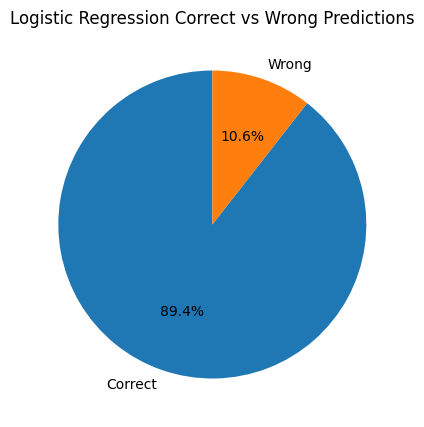

In [18]:
# Correct vs Wrong Predictions
correct = len(y_test) - len(wrong)
incorrect = len(wrong)

labels = ['Correct', 'Wrong']
values = [correct, incorrect]

plt.figure(figsize=(7,5))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Logistic Regression Correct vs Wrong Predictions")

plt.show()

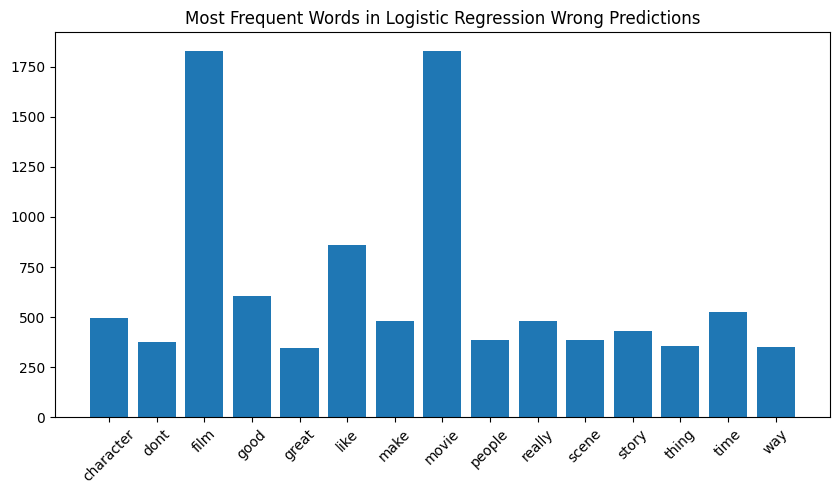

In [19]:
# Most Frequent Wrong Words
cv = CountVectorizer(
    stop_words='english',
    max_features=15
)

X_err = cv.fit_transform(
    wrong['Text'].astype(str)
)

words = cv.get_feature_names_out()
counts = X_err.toarray().sum(axis=0)

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Most Frequent Words in Logistic Regression Wrong Predictions")

plt.xticks(rotation=45)

plt.show()

# SVM Evaluation

In [20]:
# Metrics
svm_accuracy = accuracy_score(y_test, svm_preds)
svm_precision = precision_score(y_test, svm_preds)
svm_recall = recall_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds)

print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1-Score:", svm_f1)

SVM Accuracy: 0.8611
SVM Precision: 0.8556118472330475
SVM Recall: 0.8714030561619369
SVM F1-Score: 0.8634352571035296


In [21]:
# Classification Report
print(classification_report(y_test, svm_preds))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4961
           1       0.86      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



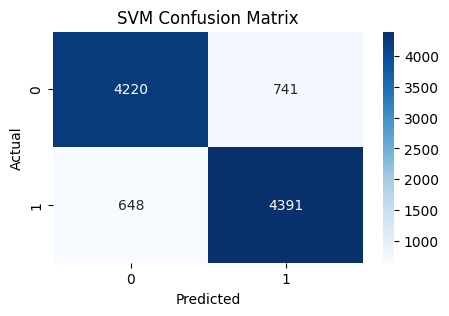

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(5,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

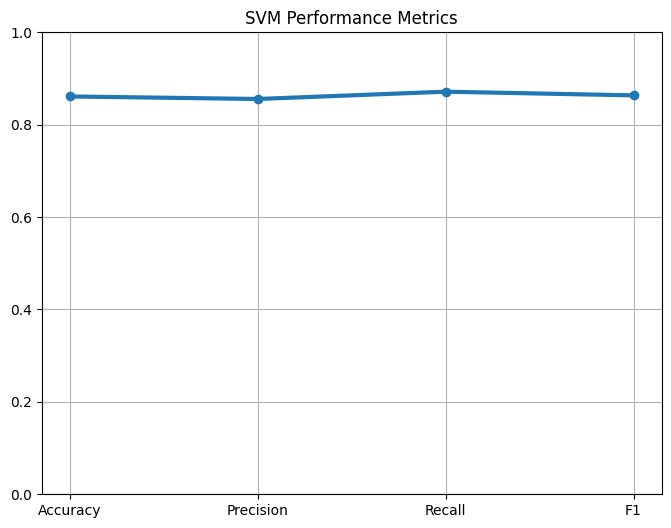

In [23]:
# Metrics Plot
metrics = [svm_accuracy, svm_precision, svm_recall, svm_f1]
names = ['Accuracy', 'Precision', 'Recall', 'F1']

plt.figure(figsize=(8,6))
plt.plot(names, metrics, marker='o', linewidth=3)

plt.ylim(0,1)
plt.title("SVM Performance Metrics")
plt.grid(True)

plt.show()

In [24]:
# Error Analysis
errors = pd.DataFrame({
    'Text': X_test['clean_review'].reset_index(drop=True),
    'True_Label': y_test,
    'Predicted_Label': svm_preds
})

wrong = errors[
    errors['True_Label'] != errors['Predicted_Label']
]

wrong.head(10)


,Text,True_Label,Predicted_Label
0,really liked summerslam due look arena curtain...,1,0
7,okay didnt get purgatory thing first time watc...,1,0
15,movie start somewhat slowly get running toward...,1,0
17,first introduced john water film seeing female...,1,0
20,production quality cast premise authentic new ...,1,0
23,movie released originally soft x apparently ex...,1,0
24,stuff going moment mj ive started listening mu...,1,0
29,three kid born solar eclipse turn vile murdero...,1,0
32,enjoy seeing must started hour movie unconnect...,0,1
41,though cant claim comic book fanatic read shar...,1,0


In [25]:
# Error Rate
print("Total Wrong Predictions:", len(wrong))
print("Total Test Samples:", len(y_test))
print("Error Rate:", len(wrong)/len(y_test))

Total Wrong Predictions: 1389
Total Test Samples: 10000
Error Rate: 0.1389


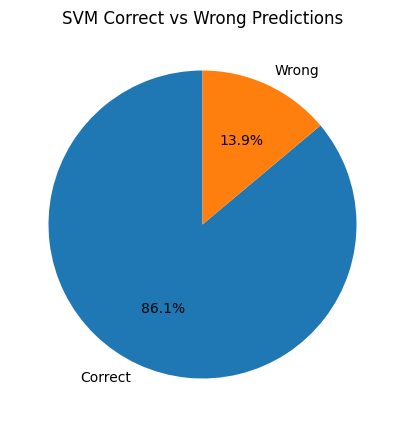

In [26]:
# Correct vs Wrong
correct = len(y_test) - len(wrong)
incorrect = len(wrong)

labels = ['Correct', 'Wrong']
values = [correct, incorrect]

plt.figure(figsize=(7,5))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("SVM Correct vs Wrong Predictions")

plt.show()

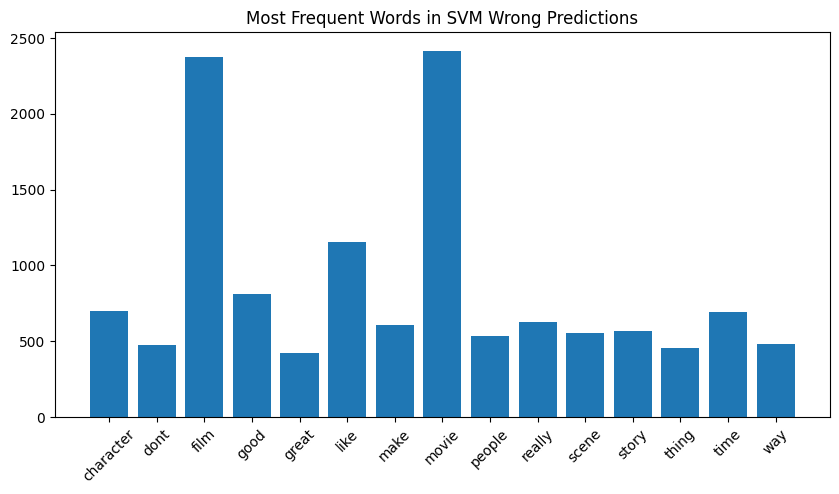

In [27]:
# Most Frequent Wrong Words
cv = CountVectorizer(
    stop_words='english',
    max_features=15
)

X_err = cv.fit_transform(
    wrong['Text'].astype(str)
)

words = cv.get_feature_names_out()
counts = X_err.toarray().sum(axis=0)

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Most Frequent Words in SVM Wrong Predictions")

plt.xticks(rotation=45)

plt.show()

# XGBoost Evaluation

In [28]:
# Metrics
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoost F1-Score:", xgb_f1)

XGBoost Accuracy: 0.847
XGBoost Precision: 0.8444924406047516
XGBoost Recall: 0.8535423695177614
XGBoost F1-Score: 0.8489932885906041


In [29]:
# Classification Report
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4961
           1       0.84      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



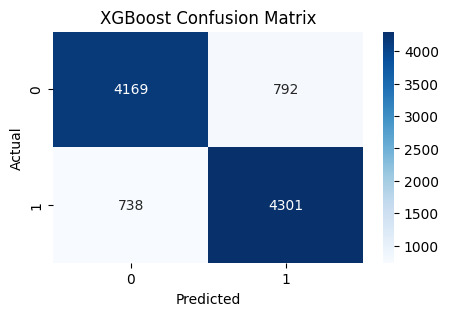

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(5,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


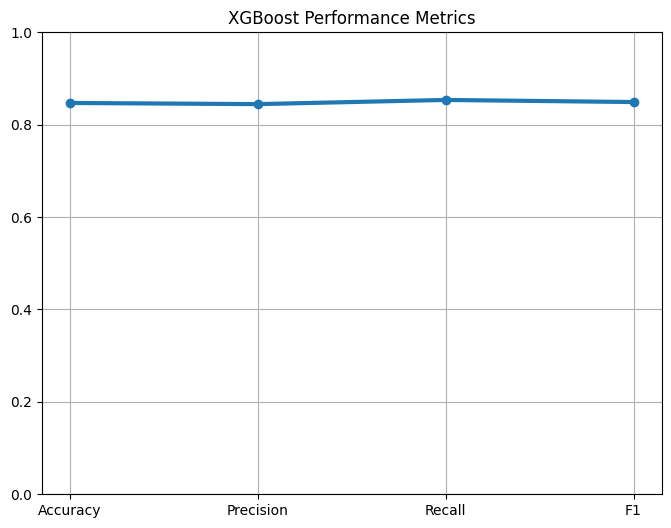

In [31]:
# Metrics Plot
metrics = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]
names = ['Accuracy', 'Precision', 'Recall', 'F1']

plt.figure(figsize=(8,6))
plt.plot(names, metrics, marker='o', linewidth=3)

plt.ylim(0,1)
plt.title("XGBoost Performance Metrics")
plt.grid(True)

plt.show()

In [32]:
# Error Analysis
errors = pd.DataFrame({
    'Text': X_test['clean_review'].reset_index(drop=True),
    'True_Label': y_test,
    'Predicted_Label': xgb_preds
})

wrong = errors[
    errors['True_Label'] != errors['Predicted_Label']
]

wrong.head(10)

,Text,True_Label,Predicted_Label
0,really liked summerslam due look arena curtain...,1,0
7,okay didnt get purgatory thing first time watc...,1,0
29,three kid born solar eclipse turn vile murdero...,1,0
30,dysfunctional family go home holiday murder ma...,0,1
32,enjoy seeing must started hour movie unconnect...,0,1
49,wasnt sure expect movie considering amazing co...,1,0
50,ruthless assassin hired eliminate someone top ...,0,1
58,although series mini film particular important...,0,1
61,longtime fan star trek seriesi found disappoin...,0,1
63,fact part liked lot interesting twist left see...,0,1


In [33]:
# Error Rate
print("Total Wrong Predictions:", len(wrong))
print("Total Test Samples:", len(y_test))
print("Error Rate:", len(wrong)/len(y_test))

Total Wrong Predictions: 1530
Total Test Samples: 10000
Error Rate: 0.153


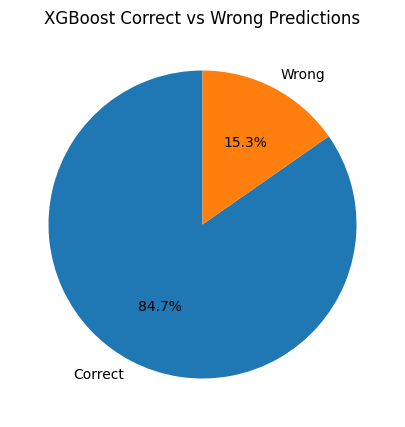

In [34]:
# Correct vs Wrong Predictions
correct = len(y_test) - len(wrong)
incorrect = len(wrong)

labels = ['Correct', 'Wrong']
values = [correct, incorrect]

plt.figure(figsize=(7,5))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("XGBoost Correct vs Wrong Predictions")

plt.show()

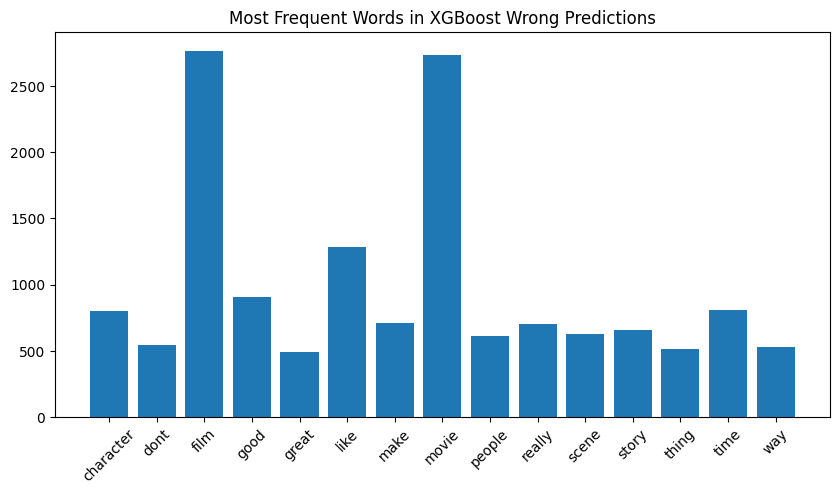

In [35]:
# Most Frequent Wrong Words
cv = CountVectorizer(
    stop_words='english',
    max_features=15
)

X_err = cv.fit_transform(
    wrong['Text'].astype(str)
)

words = cv.get_feature_names_out()
counts = X_err.toarray().sum(axis=0)

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Most Frequent Words in XGBoost Wrong Predictions")

plt.xticks(rotation=45)

plt.show()

# Final Comparison Between All Models

In [36]:
results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'SVM + Word2Vec',
        'XGBoost + Word2Vec'
    ],
    'Accuracy': [
        nb_accuracy,
        log_accuracy,
        svm_accuracy,
        xgb_accuracy
    ],
    'Precision': [
        nb_precision,
        log_precision,
        svm_precision,
        xgb_precision
    ],
    'Recall': [
        nb_recall,
        log_recall,
        svm_recall,
        xgb_recall
    ],
    'F1-Score': [
        nb_f1,
        log_f1,
        svm_f1,
        xgb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.8616,0.867042,0.856718,0.861849
1,Logistic Regression,0.8944,0.885278,0.908117,0.896552
2,SVM + Word2Vec,0.8611,0.855612,0.871403,0.863435
3,XGBoost + Word2Vec,0.8470,0.844492,0.853542,0.848993


# Comparison Graph

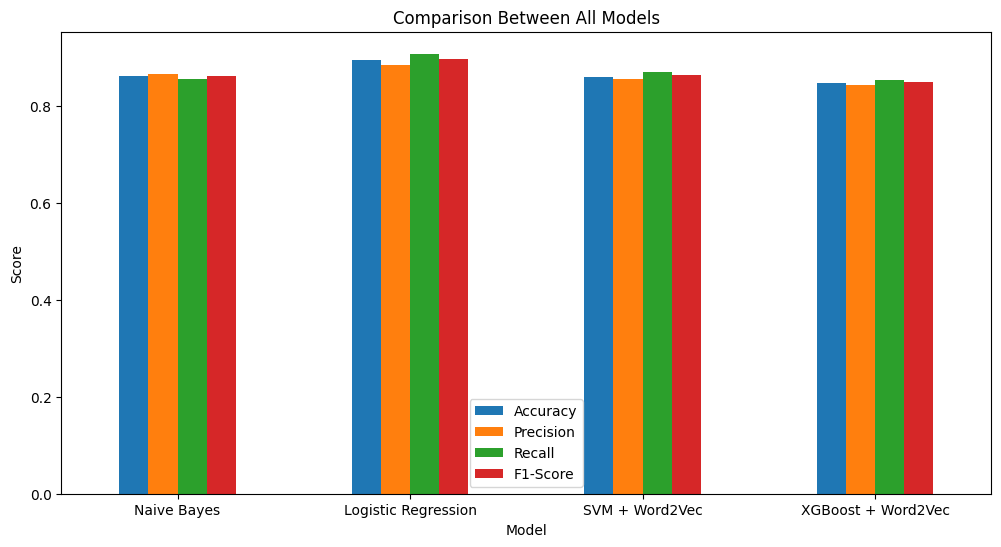

In [37]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparison Between All Models')
plt.ylabel('Score')
plt.xticks(rotation=0)

plt.show()

# Correct Expected Output

In [38]:
correct_output = pd.DataFrame({
    
    'Review': X_test['clean_review'].reset_index(drop=True).head(10),

    'Actual': y_test[:10],

    'Predicted_Naive_Bayes': y_pred_nb[:10],

    'Predicted_Logistic_Regression': y_pred_log[:10],

    'Predicted_SVM': svm_preds[:10],

    'Predicted_XGBoost': xgb_preds[:10]
})

correct_output

,Review,Actual,Predicted_Naive_Bayes,Predicted_Logistic_Regression,Predicted_SVM,Predicted_XGBoost
0,really liked summerslam due look arena curtain...,1,1,0,0,0
1,not many television show appeal quite many dif...,1,1,1,1,1
2,film quickly get major chase scene ever increa...,0,0,0,0,0
3,jane austen would definitely approve onegwynet...,1,1,1,1,1
4,expectation somewhat high went see movie thoug...,0,0,0,0,0
5,ive watched movie fairly regular basis life ne...,1,1,1,1,1
6,story hope highlighted tragic reality youth fa...,1,1,1,1,1
7,okay didnt get purgatory thing first time watc...,1,0,0,0,0
8,disappointed series lot cool graphic thats lev...,0,0,0,0,0
9,first minute tinseltown finger teetering remot...,0,0,0,0,0


In [39]:
import joblib

# Load Models

svm_model = joblib.load("../outputs/svm_model.pkl")
NAV_Log = joblib.load("../outputs/nb_model.pkl")

log_mod = joblib.load("../outputs/logistic_model.pkl")

xgb_model = joblib.load("../outputs/xgb_model.pkl")

from scipy.sparse import load_npz

X_test_tfidf = load_npz("../outputs/X_test_tfidf.npz")
X_test_vec = np.load("../outputs/X_test_vec.npy")

# ROC Comparison Plot

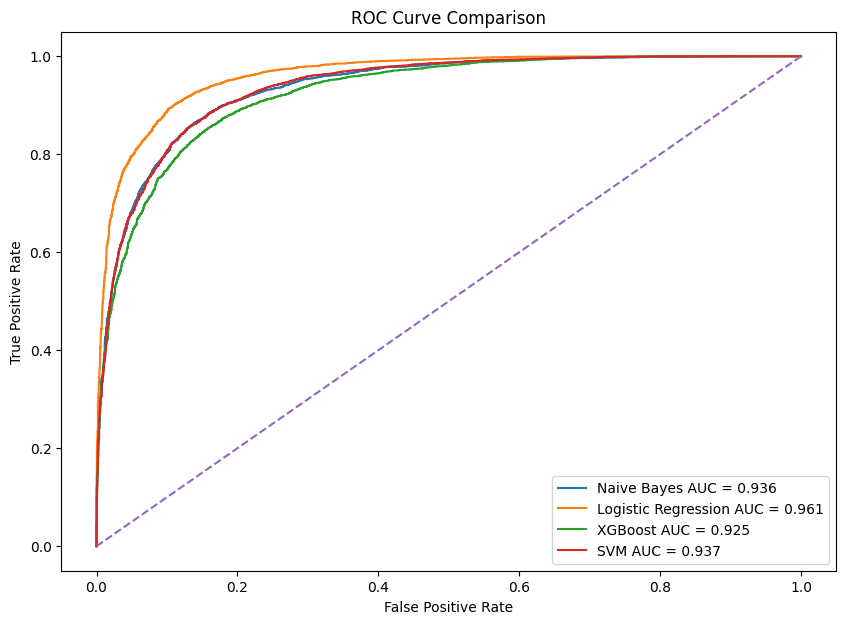

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
nb_probs = NAV_Log.predict_proba(X_test_tfidf)[:,1]

log_probs = log_mod.predict_proba(X_test_tfidf)[:,1]

xgb_probs = xgb_model.predict_proba(X_test_vec)[:,1]

svm_probs = svm_model.predict_proba(X_test_vec)[:,1]

# ROC values
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)

# AUC
auc_nb = auc(fpr_nb, tpr_nb)

auc_log = auc(fpr_log, tpr_log)

auc_xgb = auc(fpr_xgb, tpr_xgb)

auc_svm = auc(fpr_svm, tpr_svm)

# Plot
plt.figure(figsize=(10,7))

plt.plot(fpr_nb, tpr_nb,
         label=f'Naive Bayes AUC = {auc_nb:.3f}')

plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression AUC = {auc_log:.3f}')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost AUC = {auc_xgb:.3f}')

plt.plot(fpr_svm, tpr_svm,
         label=f'SVM AUC = {auc_svm:.3f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# Precision-Recal Plot


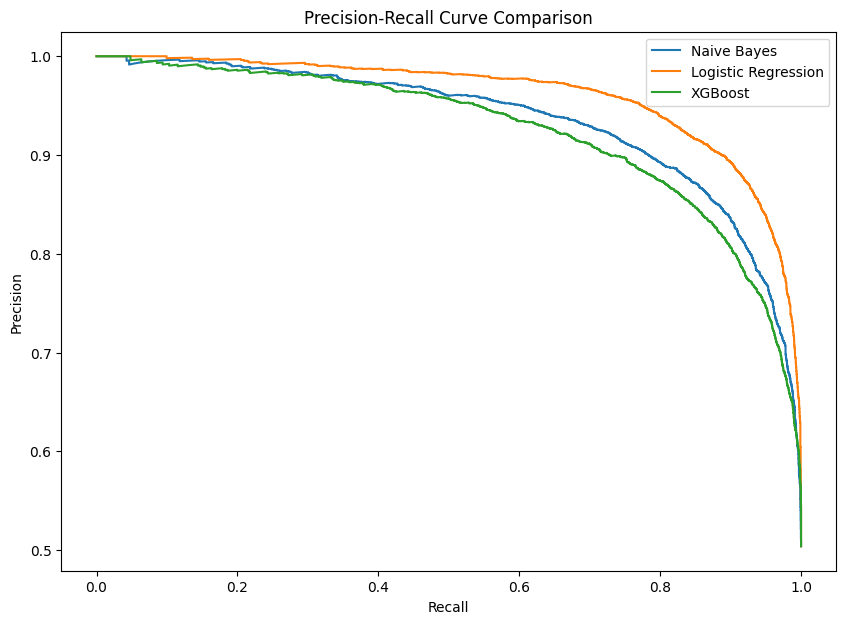

In [41]:
from sklearn.metrics import precision_recall_curve

# Curves
precision_nb, recall_nb, _ = precision_recall_curve(
    y_test, nb_probs
)

precision_log, recall_log, _ = precision_recall_curve(
    y_test, log_probs
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test, xgb_probs
)

# Plot
plt.figure(figsize=(10,7))

plt.plot(recall_nb, precision_nb,
         label='Naive Bayes')

plt.plot(recall_log, precision_log,
         label='Logistic Regression')

plt.plot(recall_xgb, precision_xgb,
         label='XGBoost')

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.show()